In [2]:
import os
import json
from shapely.geometry import Polygon
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import cv2 as cv
import numpy as np
import logging
from pathlib import Path
from typing import Union, Tuple, List, Optional
from tqdm import tqdm
from dotenv import load_dotenv

load_dotenv()
PROJECT_ROOT = os.environ.get("PROJECT_ROOT")
PYTHON_IO_ENCODING = os.environ.get("PYTHON_IO_ENCODING")

In [3]:
output_folder = os.path.join(PROJECT_ROOT, "data", "processed", "segmented_images")
files_folder = os.listdir(output_folder)

In [4]:
input_img = os.path.join(PROJECT_ROOT, "data", "processed", "extracted_lines","05_garde_001","05_garde_001_line_13.png")
img = cv.imread(input_img, cv.IMREAD_GRAYSCALE)

In [40]:
# Step 2: Apply CLAHE
clahe33 = cv.createCLAHE(clipLimit=3.0, tileGridSize=(3, 3))
img_enh_clahe33 = clahe33.apply(img)

clahe31 = cv.createCLAHE(clipLimit=3.0, tileGridSize=(3, 1))
img_enh_clahe31 = clahe31.apply(img)

# OR Step 2: Apply simple scaling
img_enh_basic = cv.convertScaleAbs(img, alpha=2.0, beta=-150)

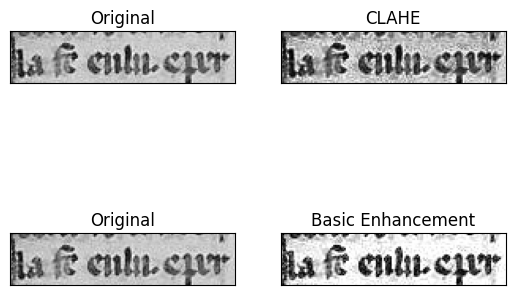

In [41]:
images = [img, img_enh_clahe33, img, img_enh_basic]
titles = ['Original', 'CLAHE', 'Original', 'Basic Enhancement']

for i in range(2):
    # Left image
    plt.subplot(2, 2, i * 2 + 1)
    plt.imshow(images[i * 2], cmap='gray')
    plt.title(titles[i * 2])
    plt.xticks([])
    plt.yticks([])

    # Right image
    plt.subplot(2, 2, i * 2 + 2)
    plt.imshow(images[i * 2 + 1], cmap='gray')
    plt.title(titles[i * 2 + 1])
    plt.xticks([])
    plt.yticks([])

plt.show()

In [42]:
def compare_binarized_img(img,gaussian_filter = (3,3)):
    ret1,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
    # Otsu's thresholding
    ret2,th2 = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
    # Otsu's thresholding after Gaussian filtering
    blur = cv.GaussianBlur(img,gaussian_filter,0)
    ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
    return th1,th2,th3

th11,th12,th13 = compare_binarized_img(img)
th21,th22,th23 = compare_binarized_img(img_enh_clahe33)
th31,th32,th33 = compare_binarized_img(img_enh_clahe31)
th41,th42,th43 = compare_binarized_img(img_enh_basic)

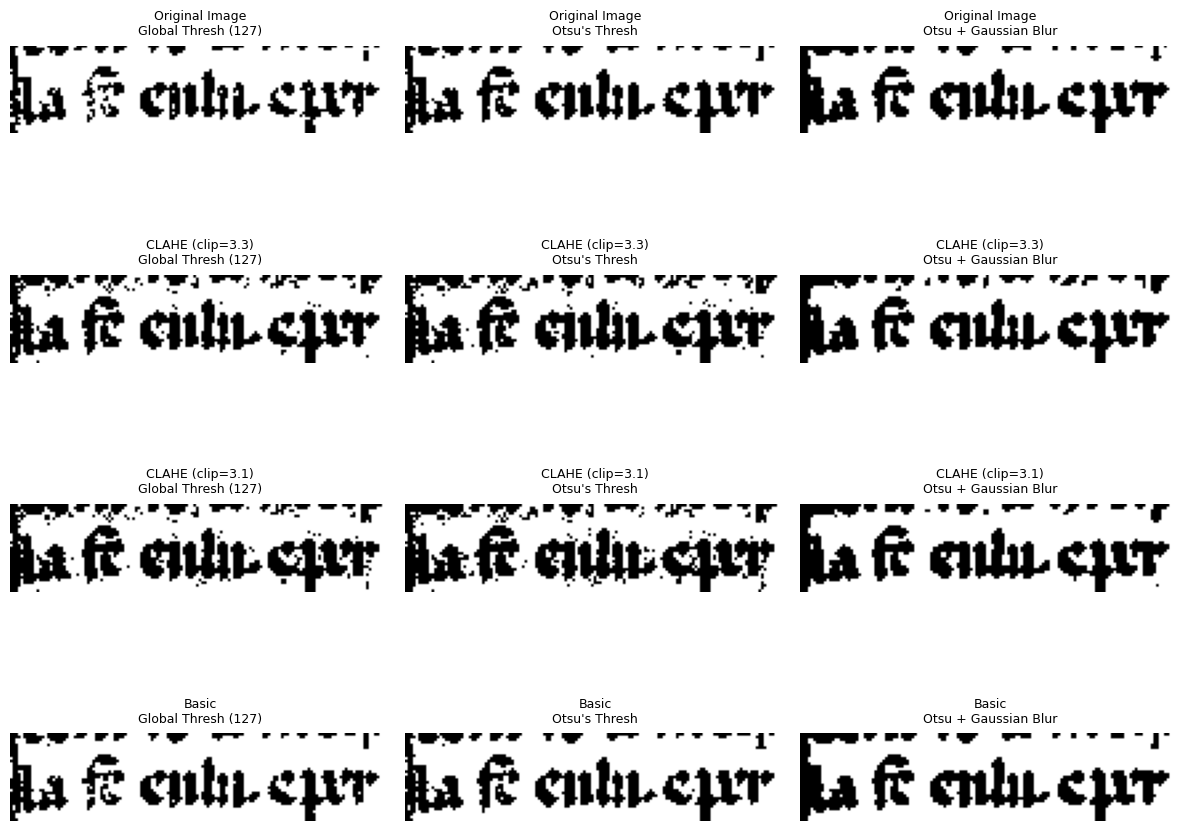

In [43]:
import matplotlib.pyplot as plt

# 1. Organize images in a 3x3 structure (rows = input, cols = method)
images = [
    [th11, th12, th13],  # Row 1: Original image
    [th21, th22, th23],  # Row 2: CLAHE enhanced (clip=3.3)
    [th31, th32, th33],   # Row 3: CLAHE enhanced (clip=3.1)
    [th41, th42, th43]   # Row 4: Basic enhancement
]

row_labels = ['Original Image', 'CLAHE (clip=3.3)', 'CLAHE (clip=3.1)','Basic']
col_labels = ['Global Thresh (127)', "Otsu's Thresh", "Otsu + Gaussian Blur"]

# 2. Create figure & axes
fig, axes = plt.subplots(4, 3, figsize=(12, 10))

# 3. Plot each image with appropriate titles
for i in range(4):
    for j in range(3):
        axes[i, j].imshow(images[i][j], cmap='gray')
        axes[i, j].set_title(f'{row_labels[i]}\n{col_labels[j]}', fontsize=9, pad=8)
        axes[i, j].axis('off')  # Hides axes ticks & spines

plt.tight_layout()  # Prevents overlapping titles/labels
plt.show()